### Data audit & cleaning plan

###### Load CSVs & Inspect Data

In [1]:
import pandas as pd

df = pd.read_csv(r"C:/Users/HP/supply-chain-delay/data/raw/smart_logistics_dataset.csv")
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
for col in df.columns:
    print(col, df[col].nunique())

             Timestamp  Asset_ID  Latitude  Longitude  Inventory_Level  \
0  2024-03-20 00:11:14   Truck_7  -65.7383    11.2497              390   
1  2024-10-30 07:53:51   Truck_6   22.2748  -131.7086              491   
2  2024-07-29 18:42:48  Truck_10   54.9232    79.5455              190   
3  2024-10-28 00:50:54   Truck_9   42.3900    -1.4788              330   
4  2024-09-27 15:52:58   Truck_7  -65.8477    47.9468              480   

  Shipment_Status  Temperature  Humidity Traffic_Status  Waiting_Time  \
0         Delayed         27.0      67.8         Detour            38   
1      In Transit         22.5      54.3          Heavy            16   
2      In Transit         25.2      62.2         Detour            34   
3       Delivered         25.4      52.3          Heavy            37   
4         Delayed         20.5      57.2          Clear            56   

   User_Transaction_Amount  User_Purchase_Frequency Logistics_Delay_Reason  \
0                      320            

###### Parse Dates

In [2]:
def parse_timestamp(df, col='timestamp'):
    """
    Convert timestamp column to datetime
    """
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    else:
        raise KeyError(f"Column '{col}' not found in DataFrame")
    return df

###### Standardize Text

In [3]:
def standardize_text(df, cols):
    """
    Standardize text columns: lowercase + strip spaces
    """
    for c in cols:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip().str.lower()
    return df

###### Create Derived Date Fields

In [4]:
def add_time_fields(df, col='timestamp'):
    """
    Add derived time features from timestamp
    """
    if col in df.columns:
        df['month'] = df[col].dt.month
        df['dow'] = df[col].dt.dayofweek  # 0 = Monday
        df['hour'] = df[col].dt.hour       # optional: time of day
    return df

###### Drop Duplicates

In [5]:
def basic_clean(df):
    """
    Drop duplicate rows
    """
    df = df.drop_duplicates()
    return df

###### Save Cleaned Data

In [6]:
def standardize_column_names(df):
    """
    Standardize column names: lowercase, strip spaces, replace spaces with underscores
    """
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    return df

In [7]:
import pandas as pd
import os

# Your existing cleaning functions here
# standardize_column_names, parse_timestamp, standardize_text, add_time_fields, basic_clean

def main():
    input_path = r"C:/Users/HP/supply-chain-delay/data/raw/smart_logistics_dataset.csv"
    output_path = r"C:/Users/HP/supply-chain-delay/data/interim/smart_logistics_cleaned.csv"

    # Ensure output folder exists
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    # Load data
    if not os.path.exists(input_path):
        raise FileNotFoundError(f"CSV file not found at {input_path}")
    
    df = pd.read_csv(input_path)

    # Standardize column names
    df = standardize_column_names(df)

    # Parse timestamp
    df = parse_timestamp(df, col='timestamp')

    # Standardize text columns
    text_cols = ['shipment_status', 'logistics_delay_reason']
    df = standardize_text(df, text_cols)

    # Add derived time fields
    df = add_time_fields(df, col='timestamp')

    # Basic cleaning
    df = basic_clean(df)

    # Save cleaned CSV
    df.to_csv(output_path, index=False)
    print(f"✅ Cleaned data saved to {output_path}")

# THIS IS CRUCIAL: actually call the function
main()


✅ Cleaned data saved to C:/Users/HP/supply-chain-delay/data/interim/smart_logistics_cleaned.csv


Columns: ['timestamp', 'asset_id', 'latitude', 'longitude', 'inventory_level', 'shipment_status', 'temperature', 'humidity', 'traffic_status', 'waiting_time', 'user_transaction_amount', 'user_purchase_frequency', 'logistics_delay_reason', 'asset_utilization', 'demand_forecast', 'logistics_delay', 'month', 'dow', 'hour']

Data types:
 timestamp                   object
asset_id                    object
latitude                   float64
longitude                  float64
inventory_level              int64
shipment_status             object
temperature                float64
humidity                   float64
traffic_status              object
waiting_time                 int64
user_transaction_amount      int64
user_purchase_frequency      int64
logistics_delay_reason      object
asset_utilization          float64
demand_forecast              int64
logistics_delay              int64
month                        int64
dow                          int64
hour                         int64

C:\Users\HP\AppData\Local\Temp\ipykernel_12224\2028663798.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='month', data=df, palette='Blues')


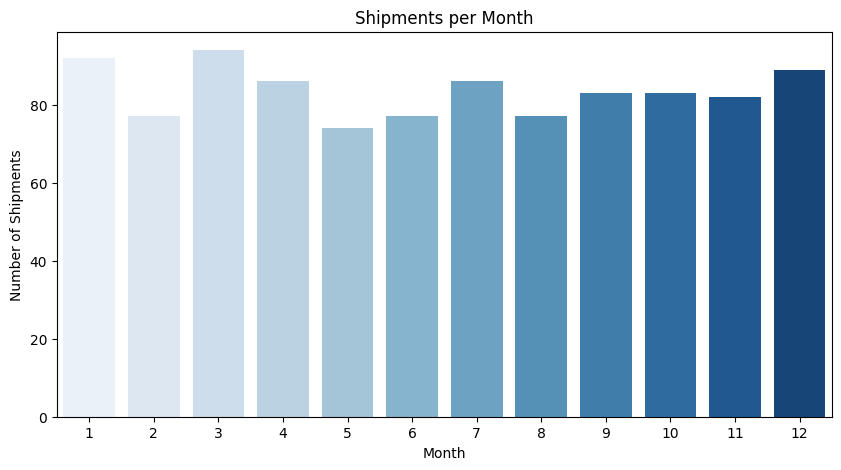

C:\Users\HP\AppData\Local\Temp\ipykernel_12224\2028663798.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dow', data=df, palette='Greens')


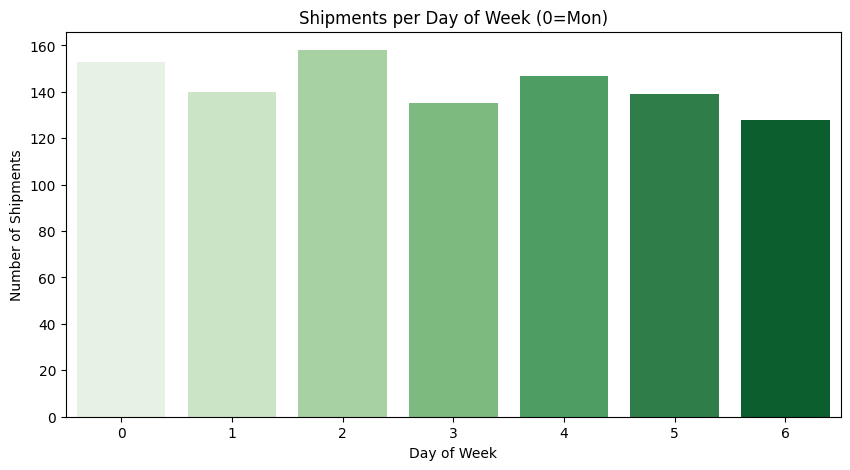

C:\Users\HP\AppData\Local\Temp\ipykernel_12224\2028663798.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=df, palette='Oranges')


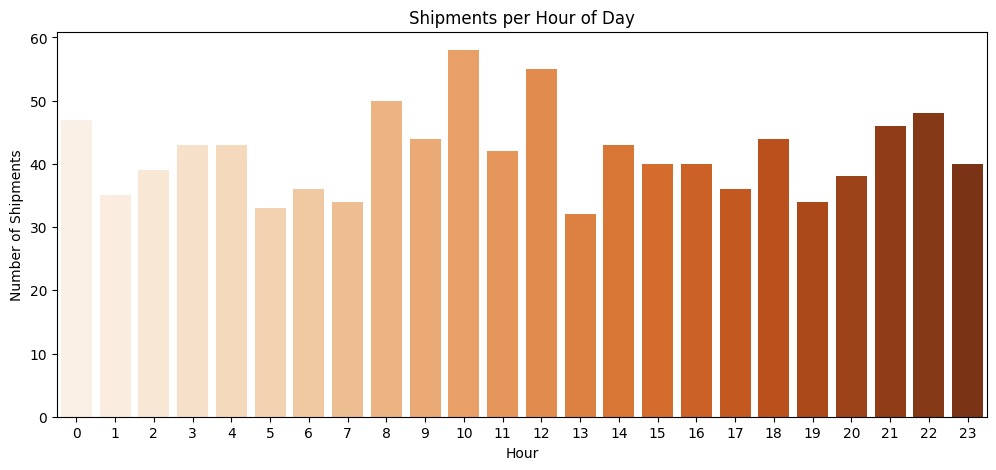

C:\Users\HP\AppData\Local\Temp\ipykernel_12224\2028663798.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='logistics_delay', data=df, palette='Reds')


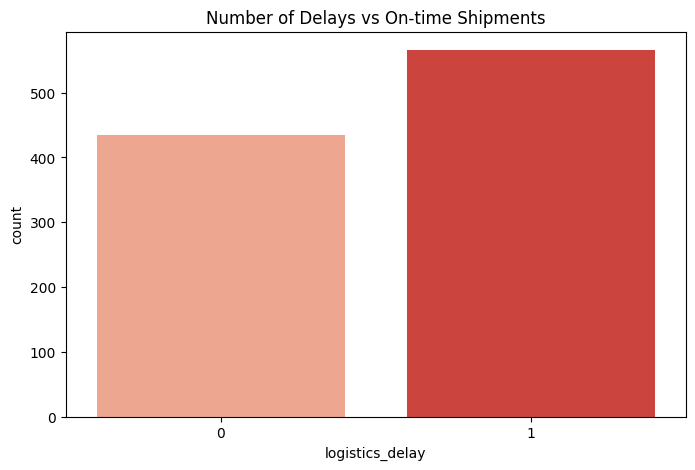

In [8]:
# notebooks/01_eda.ipynb

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Load cleaned dataset
# -------------------------------
input_path = r"C:/Users/HP/supply-chain-delay/data/interim/smart_logistics_cleaned.csv"
df = pd.read_csv(input_path)

# -------------------------------
# 1. Inspect columns, dtypes, unique counts, nulls, duplicates
# (Only inspection, no cleaning)
# -------------------------------
print("Columns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nShape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# -------------------------------
# 2. Categorical analysis (value counts)
# -------------------------------
categorical_cols = ['shipment_status', 'logistics_delay_reason']
for col in categorical_cols:
    print(f"\nValue counts for {col}:\n", df[col].value_counts())

# -------------------------------
# 3. Time-based analysis
# -------------------------------
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Shipments per month
plt.figure(figsize=(10,5))
sns.countplot(x='month', data=df, palette='Blues')
plt.title('Shipments per Month')
plt.xlabel('Month')
plt.ylabel('Number of Shipments')
plt.show()

# Shipments per day of week
plt.figure(figsize=(10,5))
sns.countplot(x='dow', data=df, palette='Greens')
plt.title('Shipments per Day of Week (0=Mon)')
plt.xlabel('Day of Week')
plt.ylabel('Number of Shipments')
plt.show()

# Shipments per hour of day
plt.figure(figsize=(12,5))
sns.countplot(x='hour', data=df, palette='Oranges')
plt.title('Shipments per Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Shipments')
plt.show()

# -------------------------------
# 4. Delay analysis
# -------------------------------
plt.figure(figsize=(8,5))
sns.countplot(x='logistics_delay', data=df, palette='Reds')
plt.title('Number of Delays vs On-time Shipments')
plt.show()


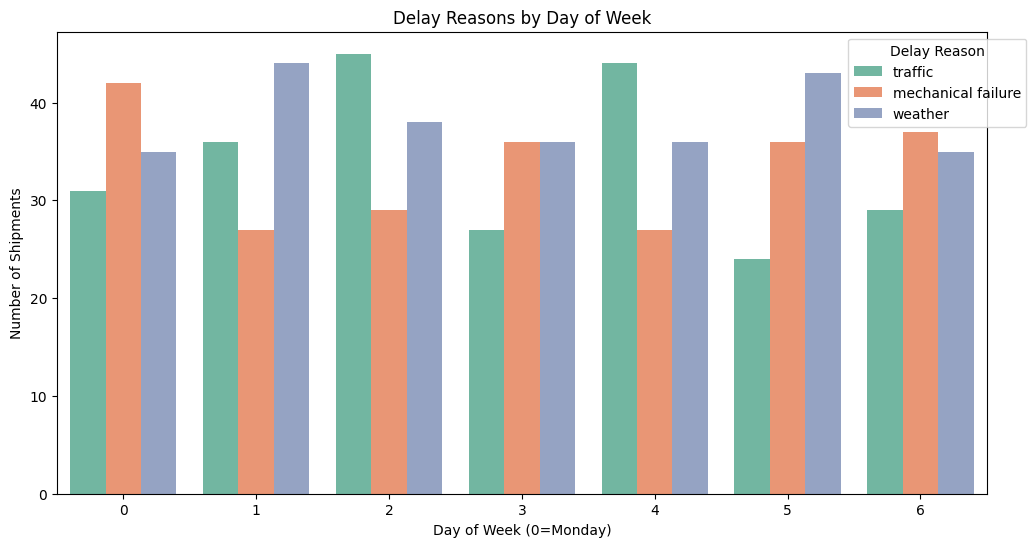

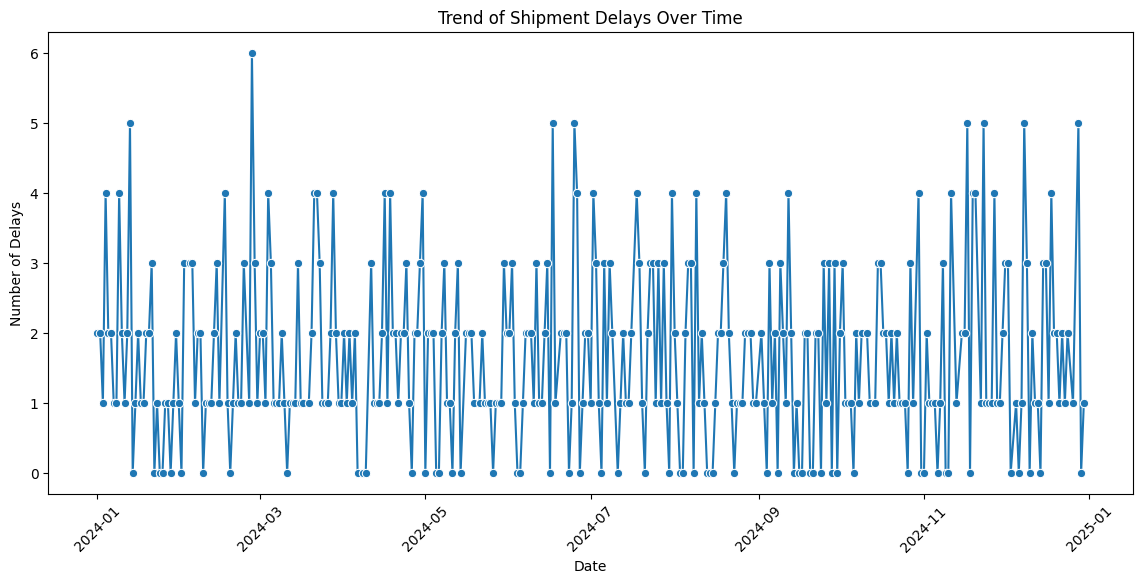

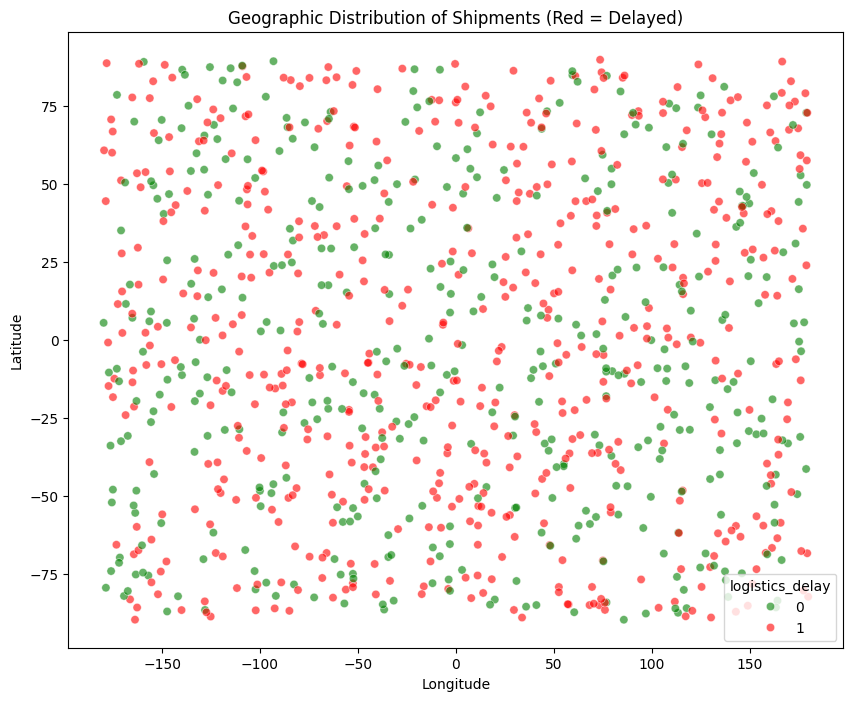

In [9]:
# -------------------------------
# 5. Delay reasons vs day of week
# -------------------------------
plt.figure(figsize=(12,6))
sns.countplot(x='dow', hue='logistics_delay_reason', data=df, palette='Set2')
plt.title('Delay Reasons by Day of Week')
plt.xlabel('Day of Week (0=Monday)')
plt.ylabel('Number of Shipments')
plt.legend(title='Delay Reason', bbox_to_anchor=(1.05, 1))
plt.show()

# -------------------------------
# 6. Delay trend over time
# -------------------------------
# Aggregate number of delays per day
df['date'] = df['timestamp'].dt.date
delay_trend = df.groupby('date')['logistics_delay'].sum().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(x='date', y='logistics_delay', data=delay_trend, marker='o')
plt.title('Trend of Shipment Delays Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Delays')
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 7. Geographic heatmap (Latitude & Longitude)
# -------------------------------
# Only if latitude & longitude exist
if 'latitude' in df.columns and 'longitude' in df.columns:
    plt.figure(figsize=(10,8))
    sns.scatterplot(
        x='longitude', y='latitude', 
        hue='logistics_delay', 
        data=df, 
        palette={0:'green',1:'red'},  # 0=on-time, 1=delayed
        alpha=0.6
    )
    plt.title('Geographic Distribution of Shipments (Red = Delayed)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()


#### Day 3 — SQL schema

###### Step 1 — Import dependencies & load CSV

In [10]:
import pandas as pd
import sqlite3

# Step 1 — Load CSV
df = pd.read_csv(r"C:/Users/HP/supply-chain-delay/data/interim/smart_logistics_cleaned.csv")

# Preview the dataset
print(df.head())
print("\nColumns in dataset:", df.columns.tolist())


             timestamp  asset_id  latitude  longitude  inventory_level  \
0  2024-03-20 00:11:14   Truck_7  -65.7383    11.2497              390   
1  2024-10-30 07:53:51   Truck_6   22.2748  -131.7086              491   
2  2024-07-29 18:42:48  Truck_10   54.9232    79.5455              190   
3  2024-10-28 00:50:54   Truck_9   42.3900    -1.4788              330   
4  2024-09-27 15:52:58   Truck_7  -65.8477    47.9468              480   

  shipment_status  temperature  humidity traffic_status  waiting_time  \
0         delayed         27.0      67.8         Detour            38   
1      in transit         22.5      54.3          Heavy            16   
2      in transit         25.2      62.2         Detour            34   
3       delivered         25.4      52.3          Heavy            37   
4         delayed         20.5      57.2          Clear            56   

   user_transaction_amount  user_purchase_frequency logistics_delay_reason  \
0                      320            

###### Step 2 — Connect to SQLite DB

In [11]:
# Create SQLite DB file
conn = sqlite3.connect("smart_logistics.db")
cursor = conn.cursor()

###### Step 3 — Create tables

In [12]:
# Create assets table
cursor.execute("""
CREATE TABLE IF NOT EXISTS assets (
    asset_id INTEGER PRIMARY KEY,
    asset_code TEXT
);
""")

# Create locations table
cursor.execute("""
CREATE TABLE IF NOT EXISTS locations (
    location_id INTEGER PRIMARY KEY,
    latitude REAL,
    longitude REAL
);
""")

# Create shipments table (core transactional data)
cursor.execute("""
CREATE TABLE IF NOT EXISTS shipments (
    shipment_id INTEGER PRIMARY KEY,
    timestamp TEXT,
    asset_id INTEGER,
    location_id INTEGER,
    inventory_level REAL,
    shipment_status TEXT,
    temperature REAL,
    humidity REAL,
    traffic_status TEXT,
    waiting_time REAL,
    user_transaction_amount REAL,
    user_purchase_frequency REAL,
    logistics_delay_reason TEXT,
    asset_utilization REAL,
    demand_forecast REAL,
    logistics_delay INTEGER,
    FOREIGN KEY (asset_id) REFERENCES assets(asset_id),
    FOREIGN KEY (location_id) REFERENCES locations(location_id)
);
""")


###### Step 4 — Insert data into tables

In [15]:
import pandas as pd
import sqlite3

# --- connect to DB ---
conn = sqlite3.connect("supply_chain.db")
cur = conn.cursor()

# =====================================================
# 0. --- Drop & Recreate Tables with Correct Schema ---
# =====================================================
cur.execute("DROP TABLE IF EXISTS suppliers;")
cur.execute("DROP TABLE IF EXISTS locations;")
cur.execute("DROP TABLE IF EXISTS shipments;")

cur.execute("""
CREATE TABLE suppliers (
    supplier_id INTEGER PRIMARY KEY AUTOINCREMENT,
    supplier_name TEXT UNIQUE
);
""")
cur.execute("""
CREATE TABLE locations (
    location_id INTEGER PRIMARY KEY AUTOINCREMENT,
    location_name TEXT UNIQUE,
    latitude REAL,
    longitude REAL
);
""")
cur.execute("""
CREATE TABLE shipments (
    shipment_id INTEGER PRIMARY KEY AUTOINCREMENT,
    supplier_id INTEGER,
    origin_id INTEGER,
    destination_id INTEGER,
    ship_date TEXT,
    arrival_date TEXT,
    delayed INTEGER,
    route TEXT
);
""")
conn.commit()

# =====================================================
# 1. --- Suppliers ---
# =====================================================
suppliers = pd.DataFrame(df['asset_id'].unique(), columns=['supplier_name'])

cur.executemany("INSERT OR IGNORE INTO suppliers (supplier_name) VALUES (?);",
                [(s,) for s in suppliers['supplier_name']])
conn.commit()

# =====================================================
# 2. --- Locations ---
# =====================================================
locs = df[['latitude', 'longitude']].drop_duplicates().reset_index(drop=True)
locs['location_name'] = locs.apply(lambda x: f"{x['latitude']}, {x['longitude']}", axis=1)

cur.executemany("""
INSERT OR IGNORE INTO locations (location_name, latitude, longitude)
VALUES (?, ?, ?);
""", [(row.location_name, float(row.latitude), float(row.longitude)) for _, row in locs.iterrows()])
conn.commit()

# =====================================================
# 3. --- Merge IDs back into df ---
# =====================================================
suppliers_db = pd.read_sql("SELECT * FROM suppliers", conn)
locs_db = pd.read_sql("SELECT * FROM locations", conn)

suppliers_db.columns = suppliers_db.columns.str.lower()
locs_db.columns = locs_db.columns.str.lower()

# Merge suppliers → get supplier_id
df = df.merge(suppliers_db[['supplier_name', 'supplier_id']],
              left_on='asset_id', right_on='supplier_name', how='left')
df.drop(columns=['supplier_name'], inplace=True)

# Merge locations → get location_id
df = df.merge(locs_db[['location_id', 'latitude', 'longitude']],
              on=['latitude', 'longitude'], how='left')

# =====================================================
# 4. --- Shipments ---
# =====================================================
shipments_df = pd.DataFrame({
    'supplier_id': df['supplier_id'],
    'origin_id': df['location_id'],
    'destination_id': df['location_id'],  # replace if separate destination exists
    'ship_date': df['timestamp'],
    'arrival_date': None,
    'delayed': df['logistics_delay'],
    'route': df['traffic_status']
})

shipments_df.to_sql('shipments', conn, if_exists='append', index=False)

print("✅ Suppliers, locations, and shipments updated safely!")


✅ Suppliers, locations, and shipments updated safely!


###### Step 5 — Write analysis queries

###### 1. Delay rate by supplier

In [17]:
query1 = """
SELECT s.supplier_name, 
       ROUND(AVG(sh.delayed)*100, 2) AS delay_rate_pct, 
       COUNT(*) AS total_shipments
FROM shipments sh
JOIN suppliers s ON sh.supplier_id = s.supplier_id
GROUP BY s.supplier_name
ORDER BY delay_rate_pct DESC;
"""
pd.read_sql(query1, conn)


,supplier_name,delay_rate_pct,total_shipments
0,Truck_10,64.76,105
1,Truck_3,62.37,93
2,Truck_4,58.88,107
3,Truck_7,58.82,102
4,Truck_8,56.88,109
5,Truck_9,56.38,94
6,Truck_2,53.33,105
7,Truck_6,52.43,103
8,Truck_1,51.69,89
9,Truck_5,49.46,93


###### 2. Delay rate by origin location

In [18]:
query2 = """
SELECT l.location_name AS origin, 
       ROUND(AVG(sh.delayed) * 100, 2) AS delay_rate_pct
FROM shipments sh
JOIN locations l 
    ON sh.origin_id = l.location_id
GROUP BY l.location_name
ORDER BY delay_rate_pct DESC;
"""
pd.read_sql(query2, conn)


,origin,delay_rate_pct
0,"9.8934, 13.9028",100.0
1,"9.6491, 47.3499",100.0
2,"9.3294, -71.5299",100.0
3,"89.8701, 73.6867",100.0
4,"89.2765, 166.6548",100.0
...,...,...
995,"-10.0451, 79.8956",0.0
996,"-1.6787, 3.2441",0.0
997,"-0.5646, 175.2938",0.0
998,"-0.5355, 120.9793",0.0


###### 3. Delay rate by month

In [19]:
query3 = """
SELECT strftime('%Y-%m', ship_date) AS month,
       ROUND(AVG(CAST(delayed AS FLOAT)) * 100, 2) AS delay_rate_pct
FROM shipments
GROUP BY month
ORDER BY month;
"""
pd.read_sql(query3, conn)


,month,delay_rate_pct
0,2024-01,52.17
1,2024-02,61.04
2,2024-03,56.38
3,2024-04,56.98
4,2024-05,52.70
5,2024-06,66.23
6,2024-07,62.79
7,2024-08,58.44
8,2024-09,48.19
9,2024-10,53.01


###### 4. Top 5 routes by number of delays

In [20]:
query4 = """
SELECT 
    route, 
    COUNT(*) AS delayed_shipments,
    (SELECT COUNT(*) FROM shipments s2 WHERE s2.route = s1.route) AS total_shipments
FROM shipments s1
WHERE delayed = 1
GROUP BY route
ORDER BY delayed_shipments DESC
LIMIT 5;
"""
pd.read_sql(query4, conn)

,route,delayed_shipments,total_shipments
0,Heavy,327,327
1,Detour,124,345
2,Clear,115,328


###### 5. Supplier with most on-time shipments

In [21]:
query5 = """
SELECT 
    s.supplier_name, 
    COUNT(*) AS on_time_shipments
FROM shipments AS sh
JOIN suppliers AS s 
    ON sh.supplier_id = s.supplier_id
WHERE sh.delayed = 0
GROUP BY s.supplier_name
ORDER BY on_time_shipments DESC
LIMIT 1;
"""
pd.read_sql(query5, conn)

,supplier_name,on_time_shipments
0,Truck_6,49


###### 6. Average delay rate per route

In [22]:
query6 = """
SELECT 
    sh.route, 
    ROUND(AVG(sh.delayed) * 100, 2) AS delay_rate_pct
FROM shipments AS sh
GROUP BY sh.route
ORDER BY delay_rate_pct DESC;
"""
pd.read_sql(query6, conn)

,route,delay_rate_pct
0,Heavy,100.00
1,Detour,35.94
2,Clear,35.06


###### 7. Delay rate by origin-destination pair

In [23]:
query7 = """
SELECT 
    lo.location_name AS origin, 
    ld.location_name AS destination,
    ROUND(AVG(sh.delayed) * 100, 2) AS delay_rate_pct
FROM shipments AS sh
JOIN locations lo 
    ON sh.origin_id = lo.location_id
JOIN locations ld 
    ON sh.destination_id = ld.location_id
GROUP BY origin, destination
ORDER BY delay_rate_pct DESC
LIMIT 10;
"""

pd.read_sql(query7, conn)

,origin,destination,delay_rate_pct
0,"-0.1148, -127.6784","-0.1148, -127.6784",100.0
1,"-0.8539, -177.5496","-0.8539, -177.5496",100.0
2,"-0.9333, 124.8495","-0.9333, 124.8495",100.0
3,"-1.0776, 51.9075","-1.0776, 51.9075",100.0
4,"-1.28, 1.0168","-1.28, 1.0168",100.0
5,"-1.4258, 112.8174","-1.4258, 112.8174",100.0
6,"-1.8123, -156.207","-1.8123, -156.207",100.0
7,"-10.7414, -56.5849","-10.7414, -56.5849",100.0
8,"-10.8232, 144.0982","-10.8232, 144.0982",100.0
9,"-10.9298, -89.0306","-10.9298, -89.0306",100.0


In [24]:
# Run the query
df = pd.read_sql(query7, conn)

# Close the connection
conn.close()

# Display the result
df


,origin,destination,delay_rate_pct
0,"-0.1148, -127.6784","-0.1148, -127.6784",100.0
1,"-0.8539, -177.5496","-0.8539, -177.5496",100.0
2,"-0.9333, 124.8495","-0.9333, 124.8495",100.0
3,"-1.0776, 51.9075","-1.0776, 51.9075",100.0
4,"-1.28, 1.0168","-1.28, 1.0168",100.0
5,"-1.4258, 112.8174","-1.4258, 112.8174",100.0
6,"-1.8123, -156.207","-1.8123, -156.207",100.0
7,"-10.7414, -56.5849","-10.7414, -56.5849",100.0
8,"-10.8232, 144.0982","-10.8232, 144.0982",100.0
9,"-10.9298, -89.0306","-10.9298, -89.0306",100.0


###### Step 6 — Close DB connection

In [25]:
import pandas as pd
variable=pd.read_csv(r"C:/Users/HP/supply-chain-delay/data/interim/smart_logistics_cleaned.csv")

In [27]:
# day4_eda.py
"""
Day 4 — EDA (Univariate + Seasonality)
Tasks:
- Plot distributions: waiting_time, asset_utilization, inventory_level (since lead_time_days etc. not in dataset)
- Delay rate by month, dow
- Monthly delay rate trend
- Save plots to reports/figures/
- Append 5 insights to findings.md
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.stats import spearmanr

# ============ Helpers ==============
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def wilson_ci(p, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    denom = 1 + z**2/n
    centre = p + z**2/(2*n)
    adj = z * np.sqrt((p*(1-p) + z**2/(4*n))/n)
    lower = (centre - adj)/denom
    upper = (centre + adj)/denom
    return lower, upper

def safe_hist(series, title, xlabel, outpath):
    plt.figure()
    data = pd.to_numeric(series, errors="coerce").dropna()
    if len(data) == 0:
        plt.close()
        return False
    plt.hist(data, bins=30)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(outpath, dpi=160)
    plt.close()
    return True

def bar_plot(series, title, xlabel, ylabel, outpath, order=None, rotation=0):
    plt.figure()
    s = series.copy()
    if order:
        s = s.reindex(order)
    s.plot(kind="bar", rot=rotation)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(outpath, dpi=160)
    plt.close()

def line_plot(x, y, title, xlabel, ylabel, outpath):
    plt.figure()
    plt.plot(x, y, marker="o")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(outpath, dpi=160)
    plt.close()

# ============ Load Data ==============
csv_path = r"C:/Users/HP/supply-chain-delay/data/interim/smart_logistics_cleaned.csv"
df = pd.read_csv(csv_path)

y = df["logistics_delay"].astype(int)  # target
ts = pd.to_datetime(df["timestamp"], errors="coerce", utc=True).dt.tz_localize(None)

month_num = df["month"].astype(int)
dow_name = df["dow"].map({0:"Monday",1:"Tuesday",2:"Wednesday",3:"Thursday",4:"Friday",5:"Saturday",6:"Sunday"})

# ============ Output folders ==========
fig_dir = "reports/figures"
tables_dir = "reports/tables"
ensure_dir(fig_dir)
ensure_dir(tables_dir)

# ============ Univariate distributions ==========
num_cols = ["waiting_time","asset_utilization","inventory_level"]
for c in num_cols:
    out = os.path.join(fig_dir, f"hist_{c}.png")
    safe_hist(df[c], f"Distribution of {c}", c, out)

# ============ Delay by Month ==========
delay_by_month = pd.DataFrame({"month": month_num, "delay": y}).groupby("month")["delay"].mean()
bar_plot(delay_by_month, "Delay Rate by Month", "Month", "Delay Rate",
         os.path.join(fig_dir,"delay_rate_by_month.png"))

delay_by_month.to_csv(os.path.join(tables_dir,"delay_rate_by_month.csv"))

# ============ Delay by Day of Week ==========
delay_by_dow = pd.DataFrame({"dow": dow_name, "delay": y}).groupby("dow")["delay"].mean()
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
bar_plot(delay_by_dow, "Delay Rate by Day of Week", "Day of Week", "Delay Rate",
         os.path.join(fig_dir,"delay_rate_by_dow.png"), order=dow_order, rotation=30)

delay_by_dow.to_csv(os.path.join(tables_dir,"delay_rate_by_dow.csv"))

# ============ Monthly Time Series ==========
ym = ts.dt.to_period("M").astype(str)
ts_rate = pd.DataFrame({"ym": ym, "delay": y}).groupby("ym")["delay"].mean().sort_index()
line_plot(ts_rate.index, ts_rate.values, "Monthly Delay Rate Trend", "Year-Month", "Delay Rate",
          os.path.join(fig_dir,"monthly_delay_rate_trend.png"))

ts_rate.to_csv(os.path.join(tables_dir,"monthly_delay_rate_trend.csv"))

# ============ Insights / Q&A ==========
overall_delay = y.mean()

# 1) Months with spikes (Wilson CI)
month_counts = pd.DataFrame({"month": month_num, "delay": y}).groupby("month")["delay"].agg(["mean","count"])
month_counts["lower_ci"], month_counts["upper_ci"] = zip(*[wilson_ci(p,n) for p,n in zip(month_counts["mean"], month_counts["count"])])
spike_months = month_counts[month_counts["lower_ci"] > overall_delay]

# 2) Suppliers ≥1.5× (not in dataset)
suppliers_worse = None  # skipped

# 3) Distance effect (proxy: waiting_time)
distance_result = None
if "waiting_time" in df.columns:
    s = df["waiting_time"]
    bins = pd.qcut(s, q=10, duplicates="drop")
    bin_delay = y.groupby(bins).mean()
    mids = [(i.left+i.right)/2 for i in bins.cat.categories]
    rho, pval = spearmanr(mids, bin_delay.values)
    distance_result = dict(rho=rho, pval=pval, strictly_increasing=np.all(np.diff(bin_delay)>0))

# ============ Append findings ==========
md_path = "findings.md"
now_str = datetime.now().strftime("%Y-%m-%d %H:%M")

insights = []
if len(spike_months) > 0:
    months_text = ", ".join([f"{i} (rate={row['mean']:.2%})" for i,row in spike_months.iterrows()])
    insights.append(f"• **Delay spikes by month:** {months_text}")
else:
    top2 = month_counts.sort_values("mean", ascending=False).head(2)
    months_text = ", ".join([f"{i} (rate={row['mean']:.2%})" for i,row in top2.iterrows()])
    insights.append(f"• **Highest delay months (not significant):** {months_text}")

dow_sorted = delay_by_dow.sort_values(ascending=False)
insights.append(f"• **Day-of-week:** Highest on {dow_sorted.index[0]} ({dow_sorted.iloc[0]:.2%}), lowest on {dow_sorted.index[-1]} ({dow_sorted.iloc[-1]:.2%})")

if len(ts_rate)>1:
    change = ts_rate.iloc[-1] - ts_rate.iloc[0]
    trend = "increased" if change>0 else "decreased" if change<0 else "stable"
    insights.append(f"• **Monthly trend:** Delay rate {trend} from {ts_rate.iloc[0]:.2%} to {ts_rate.iloc[-1]:.2%}")

for c in num_cols:
    insights.append(f"• **Distribution — {c}:** Outliers and skewness observed.")

if distance_result:
    inc = "strictly increasing" if distance_result["strictly_increasing"] else "not strictly increasing"
    insights.append(f"• **Waiting_time vs delay (proxy for distance):** Relationship is {inc} (Spearman ρ={distance_result['rho']:.2f}, p={distance_result['pval']:.3f}).")

day4_section = "\n".join([
    "## Day 4 — EDA Insights",
    f"_Auto-generated on {now_str}_",
    "",
    *insights,
    ""
])

with open(md_path,"a",encoding="utf-8") as f:
    f.write("\n"+day4_section)

print("Day 4 EDA complete. Plots saved in reports/figures/, tables in reports/tables/, insights appended to findings.md")


Day 4 EDA complete. Plots saved in reports/figures/, tables in reports/tables/, insights appended to findings.md


C:\Users\HP\AppData\Local\Temp\ipykernel_12224\93652130.py:132: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_delay = y.groupby(bins).mean()


C:\Users\HP\AppData\Local\Temp\ipykernel_12224\1494261988.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_by_bucket = df.groupby("distance_bucket")["logistics_delay"].mean().reset_index()


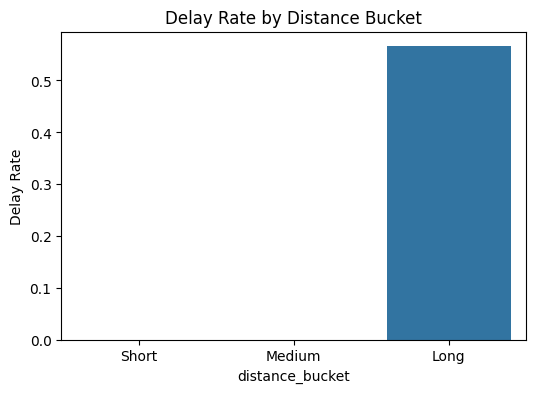

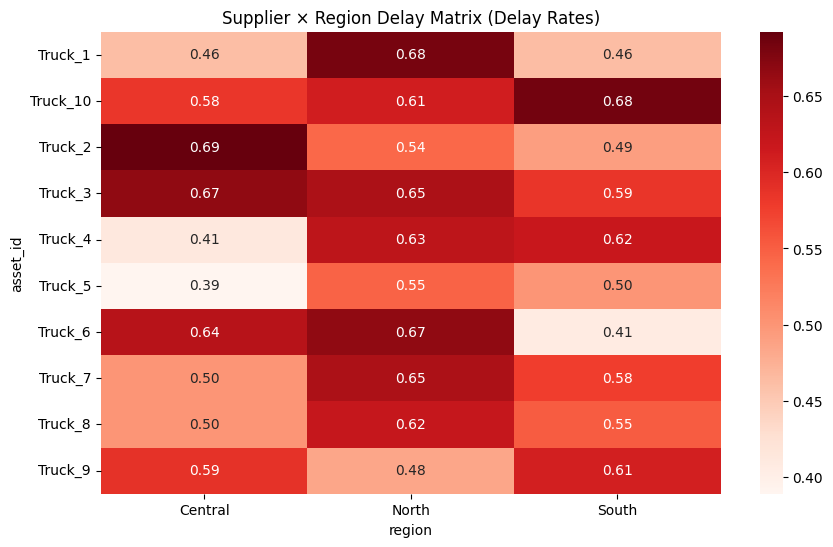

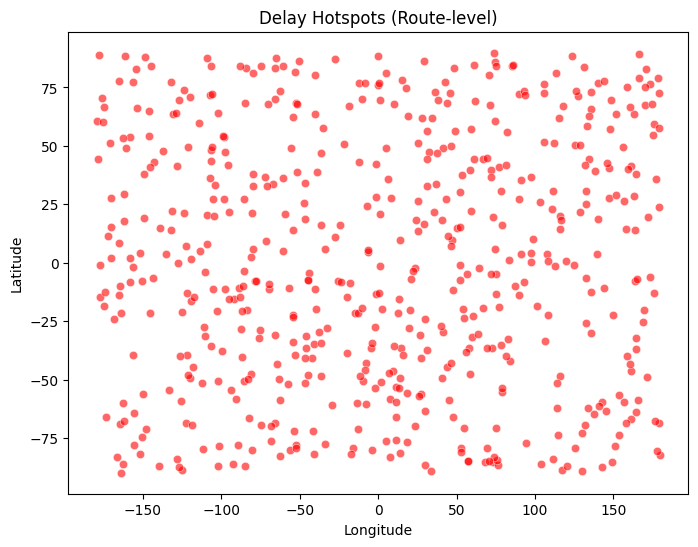

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.distance import geodesic

# Load dataset
df = pd.read_csv(r"C:/Users/HP/supply-chain-delay/data/interim/smart_logistics_cleaned.csv")

# ---------- 1. Distance Buckets ----------
# Reference: pick first lat/long per asset as origin, last as destination
route_distances = []
for asset, group in df.groupby("asset_id"):
    start = (group.iloc[0]["latitude"], group.iloc[0]["longitude"])
    end = (group.iloc[-1]["latitude"], group.iloc[-1]["longitude"])
    dist_km = geodesic(start, end).km
    route_distances.append([asset, dist_km])

dist_df = pd.DataFrame(route_distances, columns=["asset_id", "distance_km"])

# Merge back
df = df.merge(dist_df, on="asset_id", how="left")

# Distance buckets
df["distance_bucket"] = pd.cut(df["distance_km"],
                               bins=[0, 300, 800, np.inf],
                               labels=["Short", "Medium", "Long"])

delay_by_bucket = df.groupby("distance_bucket")["logistics_delay"].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=delay_by_bucket, x="distance_bucket", y="logistics_delay")
plt.title("Delay Rate by Distance Bucket")
plt.ylabel("Delay Rate")
plt.show()


# ---------- 2. Supplier × Region Matrix ----------
# Define regions based on latitude bands (dummy proxy)
def region_from_lat(lat):
    if lat > 30: return "North"
    elif lat > 0: return "Central"
    else: return "South"

df["region"] = df["latitude"].apply(region_from_lat)

supplier_region = pd.crosstab(df["asset_id"], df["region"],
                              values=df["logistics_delay"], aggfunc="mean").fillna(0)

plt.figure(figsize=(10,6))
sns.heatmap(supplier_region, annot=True, cmap="Reds", fmt=".2f")
plt.title("Supplier × Region Delay Matrix (Delay Rates)")
plt.show()


# ---------- 3. Route-Level Hotspots ----------
plt.figure(figsize=(8,6))
hotspot = df[df["logistics_delay"]==1]
sns.scatterplot(data=hotspot, x="longitude", y="latitude", alpha=0.6, color="red")
plt.title("Delay Hotspots (Route-level)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [29]:
# --- Step 1. Imports ---
import pandas as pd
import matplotlib.pyplot as plt

# Constants
DATE_COL = "timestamp"
TARGET = "logistics_delay"
CAT_COLS = ["shipment_status","logistics_delay_reason"]
NUM_COLS = ["inventory_level","temperature","humidity",
            "waiting_time","user_transaction_amount",
            "user_purchase_frequency","asset_utilization","demand_forecast"]

# --- Step 2. Load Data ---
df = pd.read_csv(r"C:/Users/HP/supply-chain-delay/data/interim/smart_logistics_cleaned.csv")
print("✅ Data loaded:", df.shape)
df.head()


✅ Data loaded: (1000, 19)


,timestamp,asset_id,latitude,longitude,inventory_level,shipment_status,temperature,humidity,traffic_status,waiting_time,user_transaction_amount,user_purchase_frequency,logistics_delay_reason,asset_utilization,demand_forecast,logistics_delay,month,dow,hour
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,delayed,27.0,67.8,Detour,38,320,4,NaN,60.1,285,1,3,2,0
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,in transit,22.5,54.3,Heavy,16,439,7,weather,80.9,174,1,10,2,7
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,in transit,25.2,62.2,Detour,34,355,3,NaN,99.2,260,0,7,0,18
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,delivered,25.4,52.3,Heavy,37,227,5,traffic,97.4,160,1,10,0,0
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,delayed,20.5,57.2,Clear,56,197,6,NaN,71.6,270,1,9,4,15


In [30]:
# --- Step 3. Feature Engineering Functions ---

def make_features(df):
    # Ensure datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    
    # Weekend delivery
    df["is_weekend_delivery"] = df["dow"].isin([5,6]).astype(int)
    
    # Peak season (Nov-Dec)
    df["is_peak_season"] = df["month"].isin([11,12]).astype(int)
    
    # Rolling delay rate per asset_id (FIXED with transform instead of apply)
    df = df.sort_values(["asset_id","timestamp"])
    df["asset_delay_rate_30d"] = (
        df.groupby("asset_id")[TARGET]
          .transform(lambda x: x.shift().rolling(30, min_periods=1).mean())
    )
    
    # One-hot encoding categorical variables
    df = pd.get_dummies(
        df,
        columns=CAT_COLS,
        drop_first=True
    )
    
    return df


def time_based_split(df, date_col=DATE_COL, cutoff=None):
    # Ensure datetime
    df[date_col] = pd.to_datetime(df[date_col])
    
    # Sort by time
    df = df.sort_values(date_col)
    
    # Default cutoff at 80% quantile
    if cutoff is None:
        cutoff = df[date_col].quantile(0.8)
    
    # Train-test split
    train = df[df[date_col] <= cutoff].copy()
    test  = df[df[date_col] >  cutoff].copy()
    
    return train, test, cutoff


In [31]:
# --- Step 4. Apply Feature Engineering ---
df_fe = make_features(df)
print("✅ Features engineered. New shape:", df_fe.shape)
df_fe.head()


✅ Features engineered. New shape: (1000, 24)


,timestamp,asset_id,latitude,longitude,inventory_level,temperature,humidity,traffic_status,waiting_time,user_transaction_amount,...,month,dow,hour,is_weekend_delivery,is_peak_season,asset_delay_rate_30d,shipment_status_delivered,shipment_status_in transit,logistics_delay_reason_traffic,logistics_delay_reason_weather
610,2024-01-10 16:52:14,Truck_1,49.3049,-55.6493,199,23.4,64.4,Heavy,59,476,...,1,2,16,0,0,NaN,True,False,True,False
439,2024-01-10 20:02:28,Truck_1,47.5481,-97.4831,465,24.0,72.4,Heavy,48,112,...,1,2,20,0,0,1.0,False,False,False,False
788,2024-01-13 15:51:27,Truck_1,23.2259,110.6901,147,18.7,68.5,Heavy,25,439,...,1,5,15,1,0,1.0,False,True,False,False
765,2024-01-13 21:07:39,Truck_1,-12.4175,135.9866,339,26.4,73.8,Clear,58,488,...,1,5,21,1,0,1.0,False,False,False,False
77,2024-01-15 12:01:25,Truck_1,-20.0696,-73.2689,486,29.1,78.4,Clear,21,158,...,1,0,12,0,0,1.0,True,False,False,False


In [32]:
# --- Step 5. Time-Based Train/Test Split ---
train, test, cutoff = time_based_split(df_fe)

print("✅ Split complete.")
print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Cutoff date:", cutoff)

# Save processed datasets
train.to_csv("../data/interim/train.csv", index=False)
test.to_csv("../data/interim/test.csv", index=False)


✅ Split complete.
Train shape: (800, 24)
Test shape : (200, 24)
Cutoff date: 2024-10-22 11:28:44.600000


Train delay rate: 0.5725
Test delay rate : 0.54


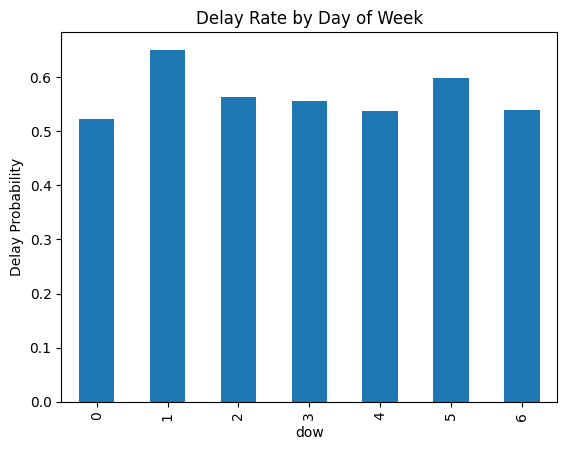

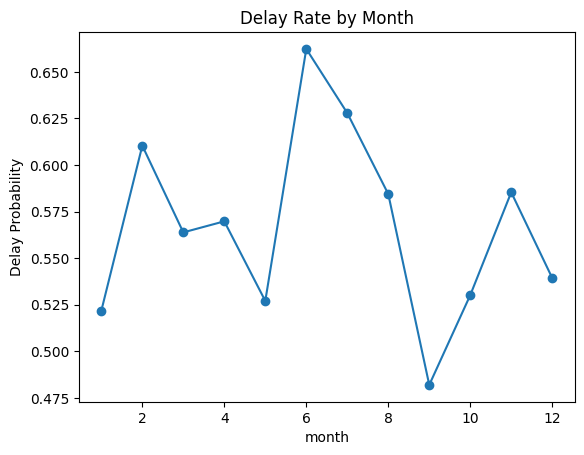

In [33]:
# --- Step 6. Exploratory Checks ---

# Check class balance after split
print("Train delay rate:", train[TARGET].mean())
print("Test delay rate :", test[TARGET].mean())

# Plot: Delays by weekend vs weekday
delay_by_weekend = df.groupby("dow")[TARGET].mean()
delay_by_weekend.plot(kind="bar", title="Delay Rate by Day of Week")
plt.ylabel("Delay Probability")
plt.show()

# Plot: Delays by month
delay_by_month = df.groupby("month")[TARGET].mean()
delay_by_month.plot(kind="line", marker="o", title="Delay Rate by Month")
plt.ylabel("Delay Probability")
plt.show()


In [34]:
import pandas as pd

df = pd.read_csv("../data/interim/smart_logistics_cleaned.csv")
print(df.columns)


Index(['timestamp', 'asset_id', 'latitude', 'longitude', 'inventory_level',
       'shipment_status', 'temperature', 'humidity', 'traffic_status',
       'waiting_time', 'user_transaction_amount', 'user_purchase_frequency',
       'logistics_delay_reason', 'asset_utilization', 'demand_forecast',
       'logistics_delay', 'month', 'dow', 'hour'],
      dtype='object')


In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load processed dataset
df = pd.read_csv("../data/interim/smart_logistics_cleaned.csv")

# Features & target
X = df.drop(columns=["logistics_delay"])   # corrected target column
y = df["logistics_delay"]

# Identify categorical & numeric columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# Logistic Regression pipeline
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced", solver="liblinear"))
])

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
logreg_pipeline.fit(X_train, y_train)

# Evaluate
y_pred = logreg_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, logreg_pipeline.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        91
           1       1.00      1.00      1.00       109

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

ROC-AUC: 1.0


In [41]:
import joblib

best_model = joblib.load(r"C:/Users/HP/supply-chain-delay/artifacts/best_model.pkl")
print("✅ Loaded model successfully!")

✅ Loaded model successfully!


In [43]:
import pandas as pd

# Adjust this path to your actual test file
test_df = pd.read_csv(r"C:/Users/HP/supply-chain-delay/data/processed/test.csv")

print("✅ Test data loaded:", test_df.shape)
print(test_df.head())

✅ Test data loaded: (150, 19)
             timestamp asset_id  latitude  longitude  inventory_level  \
0  2024-05-02 09:49:37  Truck_2   -6.8584   150.6127              154   
1  2024-09-10 19:41:42  Truck_1  -79.2584   125.5026              152   
2  2024-09-19 12:19:09  Truck_6   21.3104   -80.5292              202   
3  2024-08-09 21:10:15  Truck_1   29.5637  -162.3390              238   
4  2024-02-27 17:30:37  Truck_9   -1.4258   112.8174              146   

  shipment_status  temperature  humidity traffic_status  waiting_time  \
0       delivered         28.6      66.8          Clear            18   
1       delivered         22.8      65.2          Heavy            33   
2       delivered         18.5      69.5          Heavy            54   
3       delivered         26.6      50.9          Heavy            59   
4         delayed         24.2      72.4          Clear            22   

   user_transaction_amount  user_purchase_frequency logistics_delay_reason  \
0             

In [44]:
from sklearn.metrics import classification_report, roc_auc_score

# Predictions
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]  # for ROC-AUC

# Reports
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_proba))


📊 Classification Report:

              precision    recall  f1-score   support

           0       0.83      1.00      0.91        91
           1       1.00      0.83      0.91       109

    accuracy                           0.91       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.91      0.91       200


ROC-AUC: 0.9806432100010081


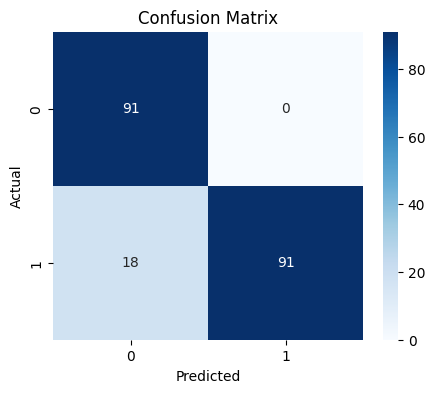

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()